# Import modules and libraries

In [1]:
# See https://simba-bio.readthedocs.io/en/latest/multiome_shareseq_GRN.html

In [132]:
import os
import numpy as np
import pandas as pd
import simba as si
import pickle

si.__version__

'1.2'

In [3]:
workdir = 'result_SIMBA'
si.settings.set_workdir(workdir)

Saving results in: result_SIMBA


In [4]:
si.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [5]:
# to make plots prettier
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

/localscratch/19785667.manuel.tardaguila/ipykernel_2634443/3381039072.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


In [6]:
import scanpy as sc

In [7]:
import re

# Load the processed files

In [9]:
workdir = '/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/QC_and_embeddings'
si.settings.set_workdir(workdir)

Saving results in: /group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/QC_and_embeddings


In [10]:
adata_C = si.read_h5ad(os.path.join(workdir,'adata_C.h5ad'))
adata_G = si.read_h5ad(os.path.join(workdir,'adata_G.h5ad'))
adata_M = si.read_h5ad(os.path.join(workdir,'adata_M.h5ad'))
adata_K = si.read_h5ad(os.path.join(workdir,'adata_K.h5ad'))
adata_P = si.read_h5ad(os.path.join(workdir,'adata_P.h5ad'))
adata_CP = si.read_h5ad(os.path.join(workdir,'adata_CP.h5ad'))

adata_PM = si.read_h5ad(os.path.join(workdir,'adata_PM.h5ad'))



adata_all = si.read_h5ad(os.path.join(workdir,'adata_all.h5ad'))

adata_cmp_CG = si.read_h5ad(os.path.join(workdir,'adata_cmp_CG.h5ad'))
adata_cmp_CM = si.read_h5ad(os.path.join(workdir,'adata_cmp_CM.h5ad'))

# Find paired TF motifs and TF genes

In [11]:
motifs_genes = pd.DataFrame(columns=['motif', 'gene'])
for x in adata_M.obs_names:
    x_split = x.split('_')
    for y in adata_G.obs_names:
        if y in x_split:
            motifs_genes.loc[motifs_genes.shape[0]] = [x,y]

In [12]:
print(motifs_genes.shape)

(577, 2)


In [13]:
motifs_genes.head()

,motif,gene
0,M_ZNF528,ZNF528
1,M_TBX19,TBX19
2,M_NRL,NRL
3,M_TBX2,TBX2
4,M_MITF,MITF


## Remove composite motifs

In [14]:
pattern = r'^M_[^_]+_[^_]+'

In [15]:
#motifs_genes["motif"]

In [16]:
# Apply regex match to each value in the Series
motifs_genes['is_composite_motif'] = motifs_genes['motif'].str.match(pattern)

## Check if there are duplicates

In [17]:
genes = motifs_genes["gene"]

In [18]:
motifs_genes[genes.isin(genes[genes.duplicated()])].sort_values("gene")

,motif,gene,is_composite_motif
11,M_BATF,BATF,False
377,M_BATF_JUN,BATF,True
494,M_FOS_JUND,FOS,True
28,M_FOS_JUN,FOS,True
241,M_FOS,FOS,False
...,...,...,...
364,M_TAL1_TCF3,TAL1,True
222,M_TCF3,TCF3,False
363,M_TAL1_TCF3,TCF3,True
345,M_RXRA_VDR,VDR,True


In [19]:
filtered = motifs_genes[motifs_genes['is_composite_motif'] == False]

In [20]:
filtered.head

<bound method NDFrame.head of         motif    gene  is_composite_motif
0    M_ZNF528  ZNF528               False
1     M_TBX19   TBX19               False
2       M_NRL     NRL               False
3      M_TBX2    TBX2               False
4      M_MITF    MITF               False
..        ...     ...                 ...
572   M_GRHL2   GRHL2               False
573    M_MAFG    MAFG               False
574   M_HESX1   HESX1               False
575    M_ESR1    ESR1               False
576   M_NR1D1   NR1D1               False

[512 rows x 3 columns]>

In [21]:
motifs = filtered["motif"]

In [22]:
filtered[motifs.isin(filtered[motifs.duplicated()])].sort_values("motif")

,motif,gene,is_composite_motif


# Create the lists

In [23]:
list_tf_motif = filtered['motif'].tolist()
list_tf_gene = filtered['gene'].tolist()

df_metrics_motif = adata_cmp_CM.var.copy()
df_metrics_gene = adata_cmp_CG.var.copy()

In [24]:
df_metrics_motif.head()

,max,std,gini,entropy
M_ZNF528,4.035833,3.054618,0.925825,7.299010
M_TBX19,2.792689,1.414291,0.696581,8.779582
M_NRL,3.826984,1.991451,0.840635,7.957233
M_TBX2,4.484378,3.388537,0.984091,4.006207
M_MITF,4.903818,3.069491,0.976440,5.796647


In [25]:
df_metrics_gene.head()

,max,std,gini,entropy
AC104472.1,1.588106,0.980425,0.502559,9.301915
AC069224.1,1.643496,1.110374,0.480881,9.343022
AC010643.1,1.725056,0.430072,0.261391,9.601311
AC006001.2,1.020812,0.416054,0.214097,9.657111
AC103739.2,2.186976,0.871057,0.457693,9.355374


# Plot SIMBA metrics in order to help set the cutoffs later

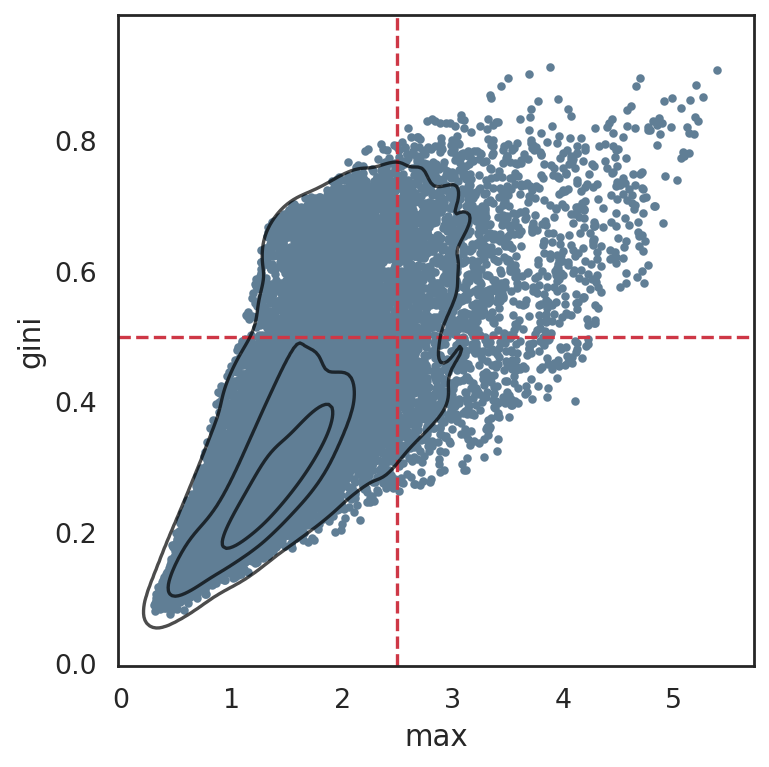

In [26]:
si.pl.entity_metrics(adata_cmp_CG,x='max',y='gini',
                     show_texts=False,
                     show_cutoff=True,
                     show_contour=True,
                     c='#607e95',
                     cutoff_x=2.5,
                     cutoff_y=0.5)

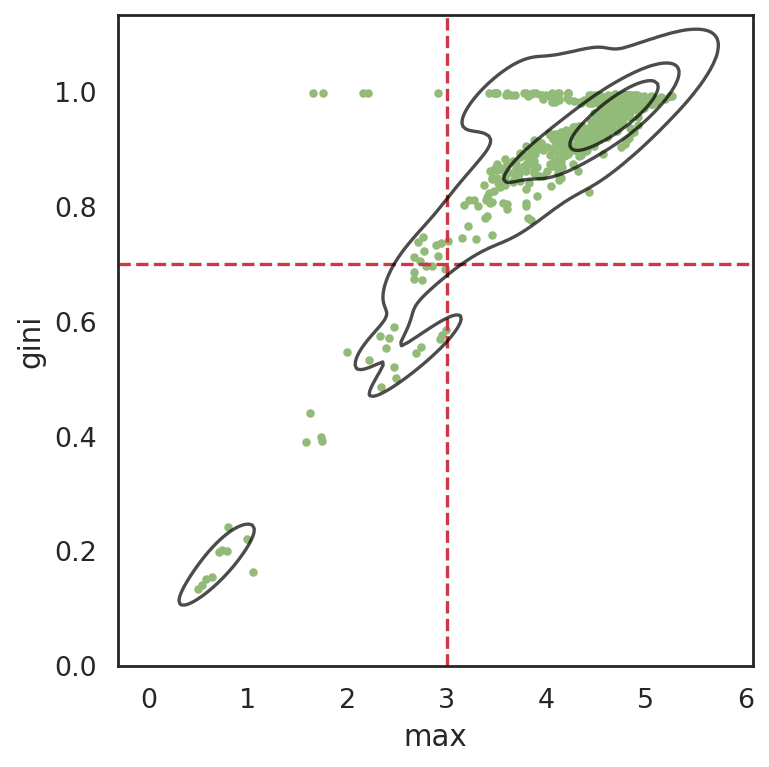

In [27]:
si.pl.entity_metrics(adata_cmp_CM,x='max',y='gini',
                     show_texts=False,
                     show_cutoff=True,
                     show_contour=True,
                     c='#92ba79',
                     cutoff_x=3,
                     cutoff_y=0.7)

# Identify master regulators

In [28]:
## add annotations of all entities
adata_all.obs['entity_anno'] = ""
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'celltype'].tolist()
adata_all.obs.loc[adata_G.obs_names, 'entity_anno'] = 'gene'
adata_all.obs.loc[adata_P.obs_names, 'entity_anno'] = 'peak'
adata_all.obs.loc[adata_K.obs_names, 'entity_anno'] = 'kmer'
adata_all.obs.loc[adata_M.obs_names, 'entity_anno'] = 'motif'

adata_all.obs.head()

,celltype,clone_line,Genotype,id_dataset,entity_anno
MCO_01329_ACAACAGAGAGGCTAA-1,PolyPlo MK,rs62237617_3,rs62237617,ref,PolyPlo MK
MCO_01329_GAACCAAAGGAAACTG-1,MK,rs62237617_3,rs62237617,ref,MK
MCO_01326_CAATGACTCACTTCAT-1,hESC,DNMT3A_3,DNMT3A,ref,hESC
MCO_01329_CGCCTCATCACCTGCT-1,PolyPlo MK,rs62237617_3,rs62237617,ref,PolyPlo MK
MCO_01328_CAGCATGTCGGTCAAT-1,early erythroid,rs62237617_3,rs62237617,ref,early erythroid


In [29]:
df_MR = si.tl.find_master_regulators(adata_all,
                                     list_tf_motif=list_tf_motif,
                                     list_tf_gene=list_tf_gene,
                                     cutoff_gene_max=2.5,
                                     cutoff_gene_gini=0.5,
                                     cutoff_motif_max=3,
                                     cutoff_motif_gini=0.7,
                                     metrics_gene=df_metrics_gene,
                                     metrics_motif=df_metrics_motif
                                    )

Adding motif metrics ...
Adding gene metrics ...
Computing distances between TF motifs and genes ...


/group/soranzo/conda_envs/env_simba/lib/python3.11/site-packages/simba/tools/_post_training.py:619: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.984223916294711' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_MR.loc[i, 'dist'] = dist_MG.loc[x_motif, x_gene]


filtering master regulators based on gene metrics:
Gini index
max
filtering master regulators based on motif metrics:
Gini index
max


In [30]:
df_MR

,motif,gene,rank,dist,max_motif,std_motif,gini_motif,entropy_motif,max_gene,std_gene,gini_gene,entropy_gene
0,M_BHLHE40,BHLHE40,4493,2.437036,4.852251,2.863262,0.968569,6.043483,2.666047,1.237764,0.623060,8.973866
1,M_NR2F2,NR2F2,9382,3.128698,4.574740,3.631112,0.991386,3.687594,4.275873,1.057720,0.675748,8.316953
2,M_GFI1,GFI1,12951,3.597887,4.427261,2.350672,0.910934,7.234061,2.997359,1.828487,0.794219,8.346111
3,M_ERG,ERG,14140,4.515230,4.206172,3.560870,0.988479,3.434817,2.592819,1.192153,0.617743,8.988928
4,M_VDR,VDR,18160,3.989766,4.440513,2.239815,0.913473,7.047473,2.803409,1.399613,0.674158,8.862799
...,...,...,...,...,...,...,...,...,...,...,...,...
60,M_TFAP2A,TFAP2A,30435,6.339508,4.747169,3.755264,0.987383,4.333864,4.636888,1.037417,0.694677,7.933240
61,M_HOXB7,HOXB7,30445,5.561134,4.565736,2.986840,0.939684,6.689368,4.092317,1.087715,0.674427,8.317889
62,M_NKX2-5,NKX2-5,30473,5.786622,3.650020,2.142714,0.858579,7.960331,4.689298,0.670961,0.654210,7.727719
63,M_SOX18,SOX18,30481,5.768755,3.507237,2.143480,0.850419,8.023769,4.397210,1.372419,0.757942,7.963337


# Identify target genes

## make sure the indices of motifs are the same as in `motifs_genes`

In [31]:
adata_PM.var.index = 'M_' + adata_PM.var.index

## get the overlap between peaks and gene loci

In [32]:
reference_genome = '/processing_data/reference_datasets/iGenomes/2022.1/Homo_sapiens/NCBI/GRCh38/Sequence/WholeGenomeFasta/genome.fa'

In [35]:
adata_CP

AnnData object with n_obs × n_vars = 16835 × 306645
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_RNA_raw', 'nFeature_RNA_raw', 'nCount_ATAC', 'nFeature_ATAC', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'TSS.enrichment', 'TSS.percentile', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'scDblFinder.class_atac', 'scDblF

In [38]:
adata_CP.var_names

Index(['chr1-10052-10333', 'chr1-180682-181613', 'chr1-191201-191943',
       'chr1-267869-268076', 'chr1-629782-630038', 'chr1-631529-631802',
       'chr1-633775-634127', 'chr1-778261-779284', 'chr1-817112-817408',
       'chr1-821228-821492',
       ...
       'chrY-19744128-19745282', 'chrY-19758681-19759055',
       'chrY-20575012-20576178', 'chrY-21240309-21240531',
       'chrY-26408479-26409615', 'chrY-26447955-26448373',
       'chrY-26670540-26671277', 'chrY-56829559-56829775',
       'chrY-56836647-56836946', 'chrY-56850762-56850975'],
      dtype='object', length=306645)

### Print the first few to see the format

In [47]:
adata_CP.var_names[:5].to_list()

['chr1-10052-10333',
 'chr1-180682-181613',
 'chr1-191201-191943',
 'chr1-267869-268076',
 'chr1-629782-630038']

### Extrat chr start and end as separate columns in ann data

In [59]:
# Split var_names into chrosome, start, and end positions
adata_CP.var[['chrom', 'start', 'end']] = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')


In [60]:
adata_CP.var[['chrom']]

,chrom
chr1-10052-10333,NaN
chr1-180682-181613,NaN
chr1-191201-191943,NaN
chr1-267869-268076,NaN
chr1-629782-630038,NaN
...,...
chrY-26447955-26448373,NaN
chrY-26670540-26671277,NaN
chrY-56829559-56829775,NaN
chrY-56836647-56836946,NaN


In [63]:
matched = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')

matched


,0,1,2
0,chr1,10052,10333
1,chr1,180682,181613
2,chr1,191201,191943
3,chr1,267869,268076
4,chr1,629782,630038
...,...,...,...
306640,chrY,26447955,26448373
306641,chrY,26670540,26671277
306642,chrY,56829559,56829775
306643,chrY,56836647,56836946


In [62]:
# Check rows where it failed
bad_rows = adata_CP.var_names[matched.isnull().any(axis=1)]
bad_rows[:10].to_list()  # Print first few problem entries

[]

In [65]:
matched.keys

<bound method NDFrame.keys of            0         1         2
0       chr1     10052     10333
1       chr1    180682    181613
2       chr1    191201    191943
3       chr1    267869    268076
4       chr1    629782    630038
...      ...       ...       ...
306640  chrY  26447955  26448373
306641  chrY  26670540  26671277
306642  chrY  56829559  56829775
306643  chrY  56836647  56836946
306644  chrY  56850762  56850975

[306645 rows x 3 columns]>

In [68]:
# Extract chromosome, start, end from var_names
adata_CP.var[['chrom', 'start', 'end']] = adata_CP.var_names.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')


In [69]:
adata_CP.var[['chrom', 'start', 'end']].head()


,chrom,start,end
chr1-10052-10333,NaN,NaN,NaN
chr1-180682-181613,NaN,NaN,NaN
chr1-191201-191943,NaN,NaN,NaN
chr1-267869-268076,NaN,NaN,NaN
chr1-629782-630038,NaN,NaN,NaN


In [70]:
print(type(adata_CP.var_names))

<class 'pandas.core.indexes.base.Index'>


#### Convert index

In [97]:
var_names_str = adata_CP.var_names.astype(str)

var_names_str

Index(['chr1-10052-10333', 'chr1-180682-181613', 'chr1-191201-191943',
       'chr1-267869-268076', 'chr1-629782-630038', 'chr1-631529-631802',
       'chr1-633775-634127', 'chr1-778261-779284', 'chr1-817112-817408',
       'chr1-821228-821492',
       ...
       'chrY-19744128-19745282', 'chrY-19758681-19759055',
       'chrY-20575012-20576178', 'chrY-21240309-21240531',
       'chrY-26408479-26409615', 'chrY-26447955-26448373',
       'chrY-26670540-26671277', 'chrY-56829559-56829775',
       'chrY-56836647-56836946', 'chrY-56850762-56850975'],
      dtype='object', length=306645)

#### Create a separate table with the extraction of the fields

In [98]:
test = var_names_str.str.extract(r'(chr[\w]+)-(\d+)-(\d+)')

test.columns = ['chr', 'start', 'end']
test.index = adata_CP.var_names

print(test[:5]) 

                     chr   start     end
chr1-10052-10333    chr1   10052   10333
chr1-180682-181613  chr1  180682  181613
chr1-191201-191943  chr1  191201  191943
chr1-267869-268076  chr1  267869  268076
chr1-629782-630038  chr1  629782  630038


#### Assign the table to the columns

In [99]:
adata_CP.var[['chr', 'start', 'end']] = test

In [100]:
adata_CP.var[['chr', 'start', 'end']]

,chr,start,end
chr1-10052-10333,chr1,10052,10333
chr1-180682-181613,chr1,180682,181613
chr1-191201-191943,chr1,191201,191943
chr1-267869-268076,chr1,267869,268076
chr1-629782-630038,chr1,629782,630038
...,...,...,...
chrY-26447955-26448373,chrY,26447955,26448373
chrY-26670540-26671277,chrY,26670540,26671277
chrY-56829559-56829775,chrY,56829559,56829775
chrY-56836647-56836946,chrY,56836647,56836946


#### change start and end to integers

In [101]:
adata_CP.var[['start', 'end']] = adata_CP.var[['start', 'end']].astype(int)

## Gene scores tool

In [102]:
_ = si.tl.gene_scores(adata_CP,genome='hg38',use_gene_weigt=True,use_top_pcs=False)

Gene scores are being calculated for the first time
`use_precomputed` has been ignored
Processing: 0.0%
Processing: 20.0%
Processing: 40.0%
Processing: 60.0%
Processing: 80.0%


## Create the dict of tf targets

In [103]:
dict_tf_targets = si.tl.find_target_genes(adata_all,
                                          adata_PM,
                                          list_tf_motif=list_tf_motif,
                                          list_tf_gene=list_tf_gene,
                                          adata_CP=adata_CP,
                                          cutoff_gene=5000)

Preprocessing ...
#genes: 30538
#peaks: 613291
#genes-associated peaks: 282226
computing distances between genes and genes-associated peaks ...
Saving variables into `.uns['tf_targets']` ...
searching for target genes of M_ZNF528
#candinate genes is 400
removing duplicate genes ...
removing genes that do not contain TF motif ...
#candinate genes is 205
completed: 0.0%
completed: 20.0%
completed: 40.0%
completed: 60.0%
completed: 80.0%
Pruning candidate genes based on nearby peaks ...
Pruning candidate genes based on average rank ...
searching for target genes of M_TBX19
#candinate genes is 400
removing duplicate genes ...
removing genes that do not contain TF motif ...
#candinate genes is 76
completed: 0.0%
completed: 19.7%
completed: 39.5%
completed: 59.2%
completed: 78.9%
completed: 98.7%
Pruning candidate genes based on nearby peaks ...
Pruning candidate genes based on average rank ...
searching for target genes of M_NRL
#candinate genes is 400
removing duplicate genes ...
removing 

## Check the keys

In [104]:
dict_tf_targets.keys()

dict_keys(['M_ZNF528', 'M_TBX19', 'M_NRL', 'M_TBX2', 'M_MITF', 'M_YY1', 'M_BARHL1', 'M_FOXO4', 'M_ELF4', 'M_NFIL3', 'M_ATF2', 'M_BATF', 'M_OTX2', 'M_ZNF382', 'M_EBF1', 'M_RFX7', 'M_PAX4', 'M_NR2F1', 'M_YY2', 'M_ZIC4', 'M_GATA6', 'M_FIGLA', 'M_LHX1', 'M_MLXIPL', 'M_HOXD9', 'M_RUNX3', 'M_ETV2', 'M_SNAI2', 'M_SOX21', 'M_TEF', 'M_OSR1', 'M_SOHLH2', 'M_NFATC4', 'M_CREB3', 'M_HOXC4', 'M_NFIA', 'M_FOXO6', 'M_HES1', 'M_ZNF143', 'M_NFE2L1', 'M_MEIS1', 'M_ZNF652', 'M_ESRRA', 'M_HEY2', 'M_LBX2', 'M_HEY1', 'M_NFYC', 'M_PPARG', 'M_JDP2', 'M_FOXP1', 'M_PLAG1', 'M_NR5A1', 'M_HOXB6', 'M_RAX2', 'M_FOSL2', 'M_ZBTB7C', 'M_E2F1', 'M_SPIB', 'M_SOX4', 'M_POU4F3', 'M_POU6F2', 'M_HOXD3', 'M_NOTO', 'M_HOXB9', 'M_ISX', 'M_IKZF1', 'M_ELF2', 'M_MSC', 'M_KLF9', 'M_SP9', 'M_KLF16', 'M_HOXB5', 'M_RFX1', 'M_NR1D2', 'M_HOXA10', 'M_HOXC10', 'M_OVOL1', 'M_SMAD5', 'M_RARA', 'M_CREM', 'M_ARNT2', 'M_MSX1', 'M_CREB1', 'M_E2F7', 'M_NR1H4', 'M_MEF2D', 'M_HOXC9', 'M_FOXN3', 'M_DMRT3', 'M_E2F6', 'M_ZNF263', 'M_PHOX2A', 'M_SREBF

In [129]:
matches = [key for key in dict_tf_targets.keys() if "GATA" in key]

matches

['M_GATA6', 'M_GATA3', 'M_GATA2', 'M_GATA4', 'M_GATA1', 'M_GATA5']

In [116]:
type(dict_tf_targets)

dict

In [124]:
value = dict_tf_targets.get("M_PPARG")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene
SEMA3B-AS1,1430.0,yes,154,2706,967,4183,1083,1083
TGM3,2023.0,yes,3869,177,4776,35848,891,891
SLFN12L,2688.0,yes,5208,168,193,172761,3189,3189
G6PC,2996.5,yes,5894,99,864,117516,628,628
TMEM176A,3087.0,yes,6018,156,20834,20834,654,654
GLIPR2,3472.0,yes,6761,183,7056,8205,347,347
TREM1,3636.0,yes,7206,66,226,25011,1965,1965
SYP-AS1,4138.0,yes,49,8227,829,33429,917,917
LRRC25,4632.5,yes,9117,148,1904,3434,400,400
HRH4,4633.0,yes,9094,172,4296,35027,740,740


In [130]:
value = dict_tf_targets.get("M_GATA1")

value

,average_rank,has_motif,rank_gene_to_TFmotif,rank_gene_to_TFgene,rank_peak_to_TFmotif,rank_peak2_to_TFmotif,rank_peak_to_gene,rank_peak2_to_gene
DAZAP2,3544.5,yes,6962,127,66,53025,4441,4441
IFITM2,3835.0,yes,7550,120,1720,35370,277,277
PTPN18,4146.5,yes,8182,111,166,9993,6484,6484
CITED2,4156.0,yes,8211,101,80,43707,6054,6054
TBC1D23,4440.5,yes,8767,114,2267,204823,564,564
SP100,4889.0,yes,9653,125,796,82145,5132,5132
PBX2,4895.5,yes,9616,175,875,239657,3208,3208


# SAVE RESULTS

In [131]:
adata_CP.write(os.path.join(workdir,'adata_CP.h5ad'))


In [134]:
with open('/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/QC_and_embeddings/dict_tf_targets.pickle', 'wb') as handle:
    pickle.dump(dict_tf_targets, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Read it back

In [135]:
with open('/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/Downstream_analysis_cluster_after_genotyping/result_SIMBA/QC_and_embeddings/dict_tf_targets.pickle', 'rb') as handle:
    dict_tf_targets = pickle.load(handle)

In [138]:
dict_tf_targets.keys()

dict_keys(['M_ZNF528', 'M_TBX19', 'M_NRL', 'M_TBX2', 'M_MITF', 'M_YY1', 'M_BARHL1', 'M_FOXO4', 'M_ELF4', 'M_NFIL3', 'M_ATF2', 'M_BATF', 'M_OTX2', 'M_ZNF382', 'M_EBF1', 'M_RFX7', 'M_PAX4', 'M_NR2F1', 'M_YY2', 'M_ZIC4', 'M_GATA6', 'M_FIGLA', 'M_LHX1', 'M_MLXIPL', 'M_HOXD9', 'M_RUNX3', 'M_ETV2', 'M_SNAI2', 'M_SOX21', 'M_TEF', 'M_OSR1', 'M_SOHLH2', 'M_NFATC4', 'M_CREB3', 'M_HOXC4', 'M_NFIA', 'M_FOXO6', 'M_HES1', 'M_ZNF143', 'M_NFE2L1', 'M_MEIS1', 'M_ZNF652', 'M_ESRRA', 'M_HEY2', 'M_LBX2', 'M_HEY1', 'M_NFYC', 'M_PPARG', 'M_JDP2', 'M_FOXP1', 'M_PLAG1', 'M_NR5A1', 'M_HOXB6', 'M_RAX2', 'M_FOSL2', 'M_ZBTB7C', 'M_E2F1', 'M_SPIB', 'M_SOX4', 'M_POU4F3', 'M_POU6F2', 'M_HOXD3', 'M_NOTO', 'M_HOXB9', 'M_ISX', 'M_IKZF1', 'M_ELF2', 'M_MSC', 'M_KLF9', 'M_SP9', 'M_KLF16', 'M_HOXB5', 'M_RFX1', 'M_NR1D2', 'M_HOXA10', 'M_HOXC10', 'M_OVOL1', 'M_SMAD5', 'M_RARA', 'M_CREM', 'M_ARNT2', 'M_MSX1', 'M_CREB1', 'M_E2F7', 'M_NR1H4', 'M_MEF2D', 'M_HOXC9', 'M_FOXN3', 'M_DMRT3', 'M_E2F6', 'M_ZNF263', 'M_PHOX2A', 'M_SREBF